# Adaptive memory testing analysis

This notebook reads the committed evidence artifacts directly and summarizes the PsyNet simulated export, standalone synthetic policy simulation, and performance stress output.

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 50
ATTEMPT = Path('..').resolve().parent
EVIDENCE = ATTEMPT / 'evidence'
ZIP_PATH = EVIDENCE / 'simulated_data.zip'
SIM_CSV = EVIDENCE / 'simulation_trials.csv'
PERF_JSON = EVIDENCE / 'performance.json'
print('Evidence directory:', EVIDENCE)
print('PsyNet export exists:', ZIP_PATH.exists())

Evidence directory: /workspace/challenges/adaptive-memory-testing/attempts/2026-06-14-21-07/evidence
PsyNet export exists: True


## PsyNet simulated export

The PsyNet export should contain 60 memory recall trials: 6 bots times 10 trials each. The trial table stores target string, response, exact-match score, selected length, posterior snapshot ID, acquisition values, and timing metadata.

In [2]:
with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open('data/simulated_data/regular/data/MemoryRecallTrial.csv') as f:
        trials = pd.read_csv(f)
    with zf.open('data/simulated_data/regular/data/PosteriorSnapshot.csv') as f:
        snapshots = pd.read_csv(f)

trial_summary = pd.DataFrame({
    'metric': [
        'trial rows', 'participants', 'min trials per participant',
        'max trials per participant', 'adaptive rows', 'posterior snapshots',
        'length min', 'length max', 'mean correct'
    ],
    'value': [
        len(trials), trials['participant_id'].nunique(),
        trials.groupby('participant_id').size().min(),
        trials.groupby('participant_id').size().max(),
        int(trials['adaptive_enabled'].sum()), len(snapshots),
        int(trials['selected_length'].min()), int(trials['selected_length'].max()),
        round(float(trials['score'].mean()), 3),
    ],
})
trial_summary

,metric,value
0,trial rows,60.000
1,participants,6.000
2,min trials per participant,10.000
3,max trials per participant,10.000
4,adaptive rows,60.000
5,posterior snapshots,66.000
6,length min,2.000
7,length max,20.000
8,mean correct,0.517


In [3]:
audit_cols = ['participant_id', 'selected_length', 'target_string', 'answer', 'score', 'posterior_snapshot_id', 'acquisition_value', 'fallback_reason']
trials[audit_cols].head(10)

,participant_id,selected_length,target_string,answer,score,posterior_snapshot_id,acquisition_value,fallback_reason
0,1,15,631905084359256,631905089359256,0.0,1,0.446522,NaN
1,1,20,63190508435925640603,63190508465925640603,0.0,2,0.468746,NaN
2,1,15,631905084359256,632905084359256,0.0,3,0.492672,NaN
3,1,20,63190508435925640603,63190508465925640603,0.0,4,0.576143,NaN
4,1,20,63190508435925640603,63190508465925640603,0.0,5,0.588117,NaN
5,1,20,63190508435925640603,63190508465925640603,0.0,6,0.596403,NaN
6,1,20,63190508435925640603,63190508465925640603,0.0,7,0.601714,NaN
7,1,20,63190508435925640603,63190508465925640603,0.0,8,0.605537,NaN
8,1,20,63190508435925640603,63190508465925640603,0.0,9,0.608053,NaN
9,1,16,6319050843592564,6319050823592564,0.0,10,0.609932,NaN


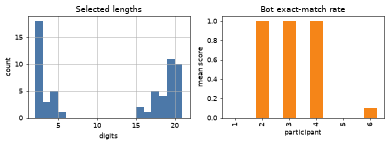

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
trials['selected_length'].hist(ax=axes[0], bins=range(2, 22), color='#4c78a8')
axes[0].set_title('Selected lengths')
axes[0].set_xlabel('digits')
axes[0].set_ylabel('count')
trials.groupby('participant_id')['score'].mean().plot(kind='bar', ax=axes[1], color='#f58518')
axes[1].set_title('Bot exact-match rate')
axes[1].set_xlabel('participant')
axes[1].set_ylabel('mean score')
plt.tight_layout()

## Standalone synthetic policy simulation

The standalone script compares adaptive mode with the disabled random-length baseline for low, medium, and high synthetic abilities.

In [5]:
sim = pd.read_csv(SIM_CSV)
sim_summary = sim.groupby(['policy', 'ability']).agg(
    mean_selected_length=('selected_length', 'mean'),
    mean_correct=('correct', 'mean'),
    mean_fit_elapsed_ms=('fit_elapsed_ms', 'mean'),
    mean_selection_elapsed_ms=('selection_elapsed_ms', 'mean'),
).round(3)
sim_summary

mean_selected_length  mean_correct  mean_fit_elapsed_ms  \
policy   ability                                                            
adaptive 0.45                     18.2           0.1               41.884   
         1.00                     19.1           0.1               44.473   
         2.50                     13.3           0.5               46.320   
random   0.45                     11.5           0.4               40.194   
         1.00                     11.5           0.3               45.117   
         2.50                      9.7           0.8               44.695   

                  mean_selection_elapsed_ms  
policy   ability                             
adaptive 0.45                       105.388  
         1.00                        50.961  
         2.50                        52.888  
random   0.45                        40.759  
         1.00                        45.725  
         2.50                        45.333

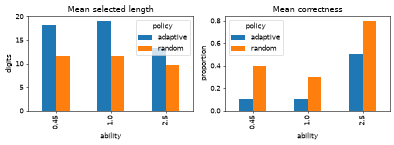

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sim_summary['mean_selected_length'].unstack('policy').plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean selected length')
axes[0].set_ylabel('digits')
sim_summary['mean_correct'].unstack('policy').plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean correctness')
axes[1].set_ylabel('proportion')
plt.tight_layout()

## Performance stress output

The required 40-bot performance test produced JSON output but did not complete bots under the stress setting. This is recorded as a scalability limitation for the Pyro adaptive policy as currently implemented.

In [7]:
with open(PERF_JSON, encoding='utf-8') as f:
    perf = json.load(f)
perf_row = perf['results'][0]
perf_summary = pd.DataFrame([
    {'metric': 'n_bots', 'value': perf_row['n_bots']},
    {'metric': 'duration_minutes', 'value': perf_row['duration_minutes']},
    {'metric': 'actual_duration_s', 'value': round(perf_row['actual_duration'], 1)},
    {'metric': 'bots_succeeded', 'value': perf_row['bots_succeeded']},
    {'metric': 'bots_incomplete', 'value': perf_row['bots_incomplete']},
    {'metric': 'bot_errors', 'value': perf_row['bot_errors']},
    {'metric': 'median_response_time_s', 'value': round(perf_row['median_response_time'], 3)},
    {'metric': 'p95_response_time_s', 'value': round(perf_row['p95_response_time'], 3)},
])
perf_summary

,metric,value
0,n_bots,40.000
1,duration_minutes,5.000
2,actual_duration_s,9011.200
3,bots_succeeded,0.000
4,bots_incomplete,14.000
5,bot_errors,0.000
6,median_response_time_s,0.556
7,p95_response_time_s,9.508


## Interpretation

The PsyNet export demonstrates that the experiment runs end to end with 10 adaptive trials per bot and exports the required audit metadata. The standalone simulation exercises both adaptive and random policies for different synthetic abilities. The current Pyro `marginal_eig` implementation is functional but not yet deployable at the 40-bot stress level: no bots completed during that run, and initialization became extremely slow. A production version should move adaptive inference off the participant response path, precompute/cap acquisition calls, or replace the expensive Pyro OED step with a faster validated approximation.